# Model Training: Artificial Neural Network
This notebook covers the building, training, and evaluation of our neural network for detecting security attacks.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Check if GPU is detected
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [2]:
# 1. Load Preprocessed Data
print("Loading data arrays...")
X_train = np.load('data/X_train.npy')
y_train = np.load('data/y_train.npy')
X_test = np.load('data/X_test.npy')
y_test = np.load('data/y_test.npy')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Loading data arrays...
X_train shape: (125973, 122)
y_train shape: (125973,)


In [3]:
# 2. Build the Artificial Neural Network
model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(500, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │        61,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,005 (250.02 KB)

 Trainable params: 64,005 (250.02 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 3. Compile the Model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [5]:
# 4. Train the Model
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

# Compute class weights to penalize mistakes on rare classes (R2L, U2R)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print(f"Class weights: {class_weights_dict}\n")

# Stop training when validation loss stops improving, and restore the best weights
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# We increase epochs to 30 because EarlyStopping will safely halt it
history = model.fit(X_train, y_train, 
                    epochs=30, 
                    batch_size=1024, 
                    validation_split=0.1,
                    class_weight=class_weights_dict,
                    callbacks=[early_stop],
                    verbose=1)

Class weights: {0: np.float64(0.5485792670977856), 1: np.float64(0.3741235169208381), 2: np.float64(2.1615133836650653), 3: np.float64(25.321206030150755), 4: np.float64(484.51153846153846)}

Epoch 1/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8769 - loss: 0.4572 - val_accuracy: 0.9259 - val_loss: 0.2063
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9368 - loss: 0.2292 - val_accuracy: 0.9412 - val_loss: 0.1870
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9439 - loss: 0.2002 - val_accuracy: 0.9531 - val_loss: 0.1441
Epoch 4/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9546 - loss: 0.1605 - val_accuracy: 0.9609 - val_loss: 0.1315
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9572 - loss: 0.1530 - val_accuracy: 0.9644 - val_loss: 0.1150
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9605 - loss: 0.1323 - val_accuracy: 0.9719 - val_loss: 0.0854
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 

In [6]:
# 5. Evaluate the Model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.7872
Test Loss: 1.2028


In [7]:
# 6. Generate Predictions and Metrics
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Alphabetical order from LabelEncoder: dos (0), normal (1), probe (2), r2l (3), u2r (4)
target_names = ['dos', 'normal', 'probe', 'r2l', 'u2r']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step

Classification Report:
              precision    recall  f1-score   support

         dos       0.95      0.82      0.88      7460
      normal       0.72      0.96      0.82      9711
       probe       0.83      0.81      0.82      2421
         r2l       0.93      0.12      0.21      2885
         u2r       0.11      0.70      0.19        67

    accuracy                           0.79     22544
   macro avg       0.71      0.68      0.58     22544
weighted avg       0.83      0.79      0.76     22544



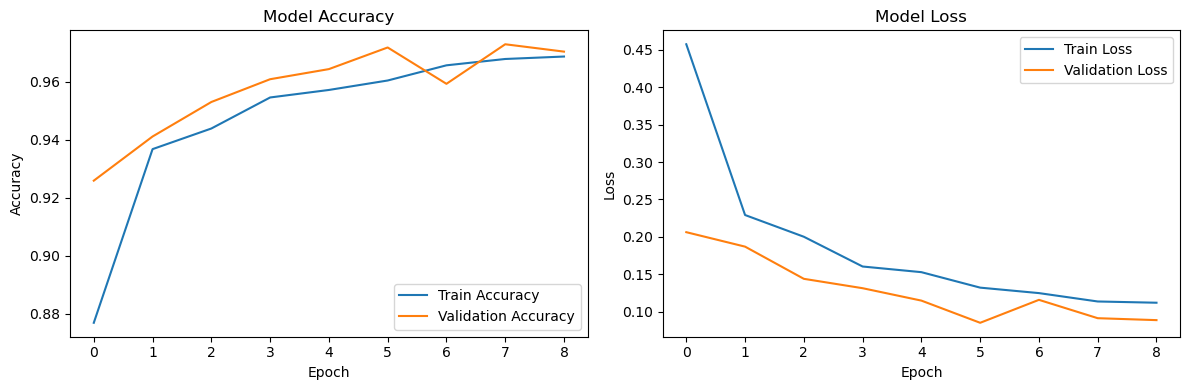

In [8]:
# 7. Plotting Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

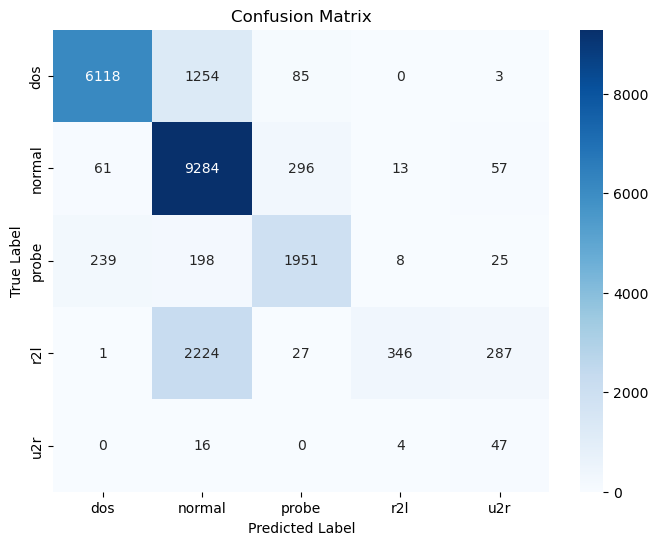

In [9]:
# 8. Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [10]:
# 9. Save the Model
model.save('security_attacks_model.keras')
print("Model saved to 'security_attacks_model.keras'")

Model saved to 'security_attacks_model.keras'
